In [1]:
from pandas import concat, read_csv

REGIONS = ('DE', 'DR', 'V')
CSV_COLUMNS = ('I', 'R', 'E', 'A', 'DE', 'DA', 'H', 'M')
NUMERIC_COLUMNS = ('DA', 'H', 'M')
converters = {
    col: lambda value: value.replace(',', '')
    for col in NUMERIC_COLUMNS
}
df = concat(
    (
        read_csv(
            f'R/{region}.csv',
            index_col='I',
            usecols=CSV_COLUMNS,
            converters=converters,
            na_filter=False
        )
        for region in REGIONS
    ),
    keys=REGIONS,
    names=('RE',)
)
df

R   E  A  DE    DA      H      M
RE I                                    
DE 1    T   0  0   8  2947   1425   4611
   1    D   1  0   3  1818      0    650
   1    D   2  0   7  4735    487    308
   1    S   1  0   3  2078   2748      0
   1    S   1  1   3   269   5848    189
...    ..  .. ..  ..   ...    ...    ...
V  491  T  12  1   9  7745     12  12986
   491  D   6  0  10  7838   1433      0
   491  D  12  2   8  8688      0    472
   491  S   2  8   7  1041  11310    256
   491  S   2  7   8  3005   8648    548

[9500 rows x 7 columns]

In [6]:
from string import digits

digit_dict = {'': 0, 'T': 1, 'D': 2, 'S': 3}
# for i, d in enumerate(digits, 1):
for i, d in enumerate(digits):
    digit_dict[d] = i
digit_dict

{'': 0,
 'T': 1,
 'D': 2,
 'S': 3,
 '0': 0,
 '1': 1,
 '2': 2,
 '3': 3,
 '4': 4,
 '5': 5,
 '6': 6,
 '7': 7,
 '8': 8,
 '9': 9}

In [7]:
from pandas import DataFrame
from numpy import uint8

result = {}
for col_name, max_len in df.map(len).max().items():
    for i in range(-max_len, 0):
        result[f'{col_name}{-i}'] = df[col_name].str[i].map(digit_dict).fillna(0).astype(uint8)
result_df = DataFrame(result)
result_df

R1  E2  E1  A2  A1  DE2  DE1  DA5  DA4  DA3  ...  H5  H4  H3  H2  H1  \
RE I                                                 ...                       
DE 1     1   0   0   0   0    0    8    0    2    9  ...   0   1   4   2   5   
   1     2   0   1   0   0    0    3    0    1    8  ...   0   0   0   0   0   
   1     2   0   2   0   0    0    7    0    4    7  ...   0   0   4   8   7   
   1     3   0   1   0   0    0    3    0    2    0  ...   0   2   7   4   8   
   1     3   0   1   0   1    0    3    0    0    2  ...   0   5   8   4   8   
...     ..  ..  ..  ..  ..  ...  ...  ...  ...  ...  ...  ..  ..  ..  ..  ..   
V  491   1   1   2   0   1    0    9    0    7    7  ...   0   0   0   1   2   
   491   2   0   6   0   0    1    0    0    7    8  ...   0   1   4   3   3   
   491   2   1   2   0   2    0    8    0    8    6  ...   0   0   0   0   0   
   491   3   0   2   0   8    0    7    0    1    0  ...   1   1   3   1   0   
   491   3   0   2   0   7    0    8    0    3    0  ...   0   8   6   4   8   

        M5  M4  M3  M2  M1  
RE I                        
DE 1     0   4   6   1   1  
   1     0   0   6   5   0  
   1     0   0   3   0   8  
   1     0   0   0   0   0  
   1     0   0   1   8   9  
...     ..  ..  ..  ..  ..  
V  491   1   2   9   8   6  
   491   0   0   0   0   0  
   491   0   0   4   7   2  
   491   0   0   2   5   6  
   491   0   0   5   4   8  

[9500 rows x 22 columns]

In [8]:
df_numpy = result_df.to_numpy().reshape(-1, 10, 22)
df_0, df_1 = df_numpy[:, :, 0], df_numpy[:, :, 1:]
df_0.shape, df_1.shape

((950, 10), (950, 10, 21))

In [10]:
from pathlib import Path
from tensorflow.random import shuffle
import tensorflow as tf
from tensorflow import gather

image_paths = sorted(map(str, Path().rglob('*.png')))
data_count = len(image_paths)
indices = shuffle(tf.range(data_count))
X_shuffled = gather(image_paths, indices)
y_shuffled_0 = gather(df_0, indices)
y_shuffled_1 = gather(df_1, indices)

train_size = int(data_count * .9)
train_X, val_X = X_shuffled[:train_size], X_shuffled[train_size:]
train_y_0, val_y_0 = y_shuffled_0[:train_size], y_shuffled_0[train_size:]
train_y_1, val_y_1 = y_shuffled_1[:train_size], y_shuffled_1[train_size:]
train_X.shape, train_y_0.shape, train_y_1.shape, val_X.shape, val_y_0.shape, val_y_1.shape

(TensorShape([855]),
 TensorShape([855, 10]),
 TensorShape([855, 10, 21]),
 TensorShape([95]),
 TensorShape([95, 10]),
 TensorShape([95, 10, 21]))

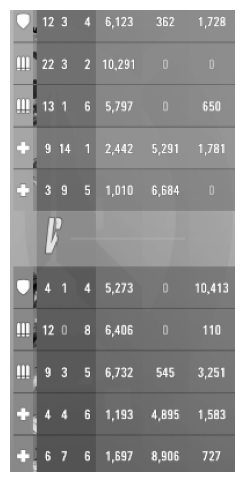

tf.Tensor(
[[1 2 0 3 0 4 0 6 1 2 3 0 0 3 6 2 0 1 7 2 8]
 [2 2 0 3 0 2 1 0 2 9 1 0 0 0 0 0 0 0 0 0 0]
 [1 3 0 1 0 6 0 5 7 9 7 0 0 0 0 0 0 0 6 5 0]
 [0 9 1 4 0 1 0 2 4 4 2 0 5 2 9 1 0 1 7 8 1]
 [0 3 0 9 0 5 0 1 0 1 0 0 6 6 8 4 0 0 0 0 0]
 [0 4 0 1 0 4 0 5 2 7 3 0 0 0 0 0 1 0 4 1 3]
 [1 2 0 0 0 8 0 6 4 0 6 0 0 0 0 0 0 0 1 1 0]
 [0 9 0 3 0 5 0 6 7 3 2 0 0 5 4 5 0 3 2 5 1]
 [0 4 0 4 0 6 0 1 1 9 3 0 4 8 9 5 0 1 5 8 3]
 [0 6 0 7 0 6 0 1 6 9 7 0 8 9 0 6 0 0 7 2 7]], shape=(10, 21), dtype=uint8)


In [11]:
from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.image import decode_png, resize
from tensorflow.io import read_file
from matplotlib.pyplot import figure, axis, imshow, show
from numpy import array


def preprocess_image(path, label):
    image = decode_png(read_file(path), channels=1)[230:930, 530:1370]
    hud_parts = [
        image[:, :40], image[:, 390:420], image[:, 450:480],
        image[:, 500:530], image[:, 570:640], image[:, 670:740], image[:, 770:]
    ]
    cropped = tf.concat(hud_parts, axis=1)
    resized = resize(cropped, (400, 194)) / 255
    return resized, label


def make_dataset(X, y, shuffle=False, batch_size=32):
    ds = Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(data_count)
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_X, train_y_1, True)
val_ds = make_dataset(val_X, val_y_1, True)
for x_batch, y_batch in train_ds.take(1):
    figure(figsize=(6, 6))
    axis('off')
    imshow(x_batch[0], cmap='gray')
    show()
    print(y_batch[0])

build_model에서 모델을 구축할 건데 Input은 흑백 이미지고 shape은 (400, 194, 1)이야. Output 1의 shape은 (10, 4)고 Output 2의 shape은 (10, 21, 11)이야. 한 이미지 내의 여러 기호와 여러 자리의 숫자를 인식하는 모델인데 각 기호 및 숫자는 최대 10 * 22(세로 * 가로) Grid 형태로 구성돼 있어. Output 1은 기호, Output 2은 숫자를 인식해야 해. 각 기호 및 숫자는 절대적인 위치는 변하지만 상대적인 순서 및 위치는 변하지 않아. 이 가로, 세로 순서를 이용하여 출력을 내는 게 중요해. 1열은 기호, 2열 ~ 22열은 숫자인 셈이지. 참고로 각 숫자는 약 9 * 16 픽셀의 크기고 인쇄 폰트 형태야. 각 기호와 숫자는 비어 있을 수도 있기 때문에 Blank를 포함해서 4 클래스와 11 클래스야. 이때 어떤 모델 구조가 가장 적합할까?

In [29]:
import tensorflow as tf
from tensorflow.keras.backend import clear_session
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    LayerNormalization,
    Dropout,
    Flatten,
    Reshape,
    MultiHeadAttention,
    Add,
    Layer,
    Lambda
)
from tensorflow.keras.losses import SparseCategoricalCrossentropy


# --------------------------
# Transformer block
# --------------------------
class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


# --------------------------
# Build OCR model
# --------------------------
def build_model():
    inputs = Input(shape=(400, 194, 1))

    # Backbone CNN
    x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)  # 400->200, 194->97

    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = Dropout(0.2)(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)  # 200->100, 97->48

    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = Dropout(0.25)(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)  # 100->50, 48->24

    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = Dropout(0.3)(x)
    x = MaxPooling2D(pool_size=(5, 1))(x)  # 50->10, 24->24

    # Reduce width to 22
    x = Lambda(lambda t: tf.image.resize(t, (10, 22)))(x)

    # x shape ≈ (10, 22, 256)
    
    # Flatten to sequence for Transformer
    seq_len = 10 * 22
    x_seq = Reshape((seq_len, 256))(x)

    # Add positional encoding (simple learned)
    pos_emb = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=256)
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_encoding = pos_emb(positions)
    pos_encoding = tf.expand_dims(pos_encoding, axis=0)  # (1, seq_len, dim)
    
    x_seq = x_seq + pos_encoding

    # Transformer blocks
    for _ in range(4):
        x_seq = TransformerBlock(embed_dim=256, num_heads=4, ff_dim=512)(x_seq)

    # Back to grid
    x_grid = Reshape((10, 22, 256))(x_seq)

    # Symbol head (column 0)
    symbol_feat = x_grid[:, :, 0, :]  # shape: (batch, 10, 256)
    # symbol_out = Dense(4, name='output_1')(symbol_feat)

    # Digit head (columns 1~21)
    digit_feat = x_grid[:, :, 1:, :]  # shape: (batch, 10, 21, 256)
    digit_out = Dense(10, name='output_2')(digit_feat)

    return Model(inputs=inputs, outputs=digit_out)

clear_session()
model = build_model()
model.compile(
    'adamw',
    SparseCategoricalCrossentropy(from_logits=True),
    metrics=['sparse_categorical_accuracy']
)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 400, 194, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 400, 194, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 200, 97, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 97, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 97, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 48, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 48, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 48, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 10, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 220, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 220, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 10, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 10, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_2 (Dense)                │ (None, 10, 21, 10)     │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,498,826 (9.53 MB)

 Trainable params: 2,498,826 (9.53 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    train_ds,
    epochs=128,
    callbacks=EarlyStopping(patience=16, verbose=1, restore_best_weights=True),
    validation_data=val_ds
)

Epoch 1/128


W0000 00:00:1774329325.279476     101 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774329326.266406     101 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_51589__.186
I0000 00:00:1774329339.642296     101 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'fusion_1524', 36 bytes spill stores, 36 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_1529', 36 bytes spill stores, 36 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_1530', 36 bytes spill stores, 36 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_1531', 64 bytes spill stores, 64 bytes spill loads



26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 3.3368 - sparse_categorical_accuracy: 0.2699

W0000 00:00:1774329343.647264      98 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774329344.465976      98 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_51589__.186
I0000 00:00:1774329357.403728      98 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'fusion_1498', 44 bytes spill stores, 44 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_1503', 44 bytes spill stores, 44 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_1504', 44 bytes spill stores, 44 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_1505', 36 bytes spill stores, 36 bytes spill loads



27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - loss: 3.3111 - sparse_categorical_accuracy: 0.2723

W0000 00:00:1774329358.507632      98 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774329358.532045      98 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_52847__.44
W0000 00:00:1774329360.442981      98 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774329360.463490      98 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_52847__.44


27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 848ms/step - loss: 2.6417 - sparse_categorical_accuracy: 0.3347 - val_loss: 1.9442 - val_sparse_categorical_accuracy: 0.4310
Epoch 2/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - loss: 1.9684 - sparse_categorical_accuracy: 0.4236 - val_loss: 1.9140 - val_sparse_categorical_accuracy: 0.4310
Epoch 3/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - loss: 1.9528 - sparse_categorical_accuracy: 0.4239 - val_loss: 1.9062 - val_sparse_categorical_accuracy: 0.4310
Epoch 4/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - loss: 1.9493 - sparse_categorical_accuracy: 0.4240 - val_loss: 1.9058 - val_sparse_categorical_accuracy: 0.4310
Epoch 5/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - loss: 1.9459 - sparse_categorical_accuracy: 0.4240 - val_loss: 1.9062 - val_sparse_categorical_accuracy: 0.4310
Epoch 6/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - loss: 1.9431 - sparse_categorical_accuracy: 0.4240 - val_loss: 1.9112 - val_sparse_categorical_accuracy: 0.4310
Epoch 7/1

In [31]:
import numpy as np
import tensorflow as tf

X_true = []
y_true = []
for X, y in val_ds:
    X_true.append(X.numpy())
    y_true.append(y.numpy())
X_true = np.concatenate(X_true, axis=0)
y_true = np.concatenate(y_true, axis=0)
X_true.shape, y_true.shape

((95, 400, 194, 1), (95, 10, 21))

In [32]:
logits = model.predict(X_true)
probs = tf.nn.softmax(logits, axis=-1)
y_pred = tf.argmax(probs, axis=-1)

I0000 00:00:1774330135.675336      99 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_78983__.35


2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

I0000 00:00:1774330137.910795      98 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_79667__.35


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step   


In [33]:
wrong_idx = tf.where(y_true != y_pred)
wrong_idx

<tf.Tensor: shape=(162, 3), dtype=int64, numpy=
array([[ 2,  1, 19],
       [ 2,  3,  9],
       [ 2,  4,  0],
       [ 2,  4,  1],
       [ 2,  4,  3],
       [ 2,  4,  5],
       [ 2,  4,  7],
       [ 2,  4,  8],
       [ 2,  4,  9],
       [ 2,  4, 10],
       [ 2,  5,  1],
       [ 2,  5,  5],
       [ 2,  5,  7],
       [ 2,  5,  8],
       [ 2,  5,  9],
       [ 2,  5, 17],
       [ 2,  5, 18],
       [ 2,  5, 19],
       [ 2,  6,  1],
       [ 2,  6,  3],
       [ 2,  6,  7],
       [ 2,  6,  8],
       [ 2,  6,  9],
       [ 2,  6, 10],
       [ 2,  6, 12],
       [ 2,  6, 14],
       [ 2,  6, 17],
       [ 2,  6, 18],
       [ 2,  6, 19],
       [ 2,  7,  0],
       [ 2,  7,  1],
       [ 2,  7,  2],
       [ 2,  7,  3],
       [ 2,  7,  5],
       [ 2,  7,  7],
       [ 2,  7,  8],
       [ 2,  7,  9],
       [ 2,  7, 13],
       [ 2,  7, 14],
       [ 2,  7, 15],
       [ 2,  7, 19],
       [ 2,  8,  1],
       [ 2,  8,  3],
       [ 2,  8,  5],
       [ 2,  8,  7],
       

In [34]:
wrong_idx[0]

<tf.Tensor: shape=(3,), dtype=int64, numpy=array([ 2,  1, 19])>

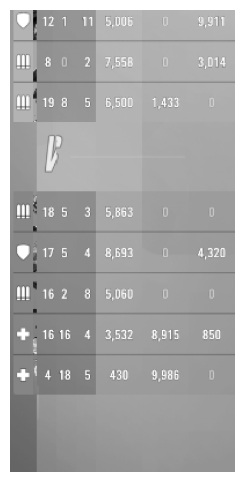

tf.Tensor(
[[1 2 0 1 1 1 0 5 0 0 6 0 0 0 0 0 0 9 9 1 1]
 [0 8 0 0 0 2 0 7 5 5 8 0 0 0 0 0 0 3 0 0 4]
 [1 9 0 8 0 5 0 6 5 0 0 0 1 4 3 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 8 0 5 0 3 0 5 8 6 3 0 0 0 0 0 0 0 0 0 0]
 [1 7 0 5 0 4 0 8 6 8 3 0 0 0 0 0 0 4 3 2 0]
 [1 6 0 6 0 4 0 3 1 5 1 0 8 0 1 0 0 0 0 5 0]
 [0 9 1 0 0 5 0 0 6 1 0 0 0 1 1 7 0 0 0 1 0]
 [1 4 1 8 0 5 0 0 4 3 3 0 9 9 8 6 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 8 0 0 0 0 0]], shape=(10, 21), dtype=int64)


In [35]:
figure(figsize=(6, 6))
axis('off')
imshow(X_true[2], cmap='gray')
show()
print(y_pred[2])

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_flatten, y_pred_flatten = y_true.reshape(-1), y_pred.numpy().reshape(-1)
cm = confusion_matrix(y_true_flatten, y_pred_flatten)
cm

array([[8541,   17,    2,    9,    6,    5,    3,    3,    5,    8],
       [  12, 2417,    1,    0,    5,    1,    0,   11,    1,    0],
       [   4,    7, 1379,   14,    1,    0,    1,   14,    0,    0],
       [   2,    1,   16, 1168,    8,   13,    0,    1,    0,   10],
       [   9,    3,    6,    7, 1110,    1,    0,    6,    1,    0],
       [   5,    1,    2,    4,    0, 1084,    9,    0,    1,   11],
       [   4,    0,    1,    0,    0,   13, 1048,    0,   10,    4],
       [   0,   14,   12,    0,    2,    0,    1,  976,    0,    0],
       [   3,    0,    1,    0,    1,    0,   10,    1,  980,   10],
       [   5,    0,    0,    2,    1,    2,    3,    1,   18,  881]])

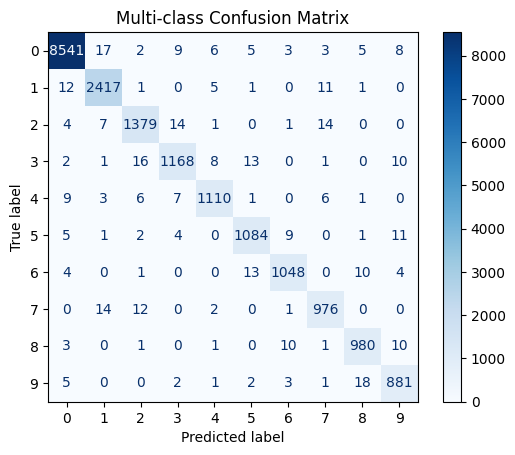

In [19]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Multi-class Confusion Matrix")
plt.show()